In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 
import torch.nn.functional as F
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
np.random.seed(0)
torch.manual_seed(0)
random.seed(0)


# Data

In [2]:

transform = transforms.ToTensor()

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=128, shuffle=False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')


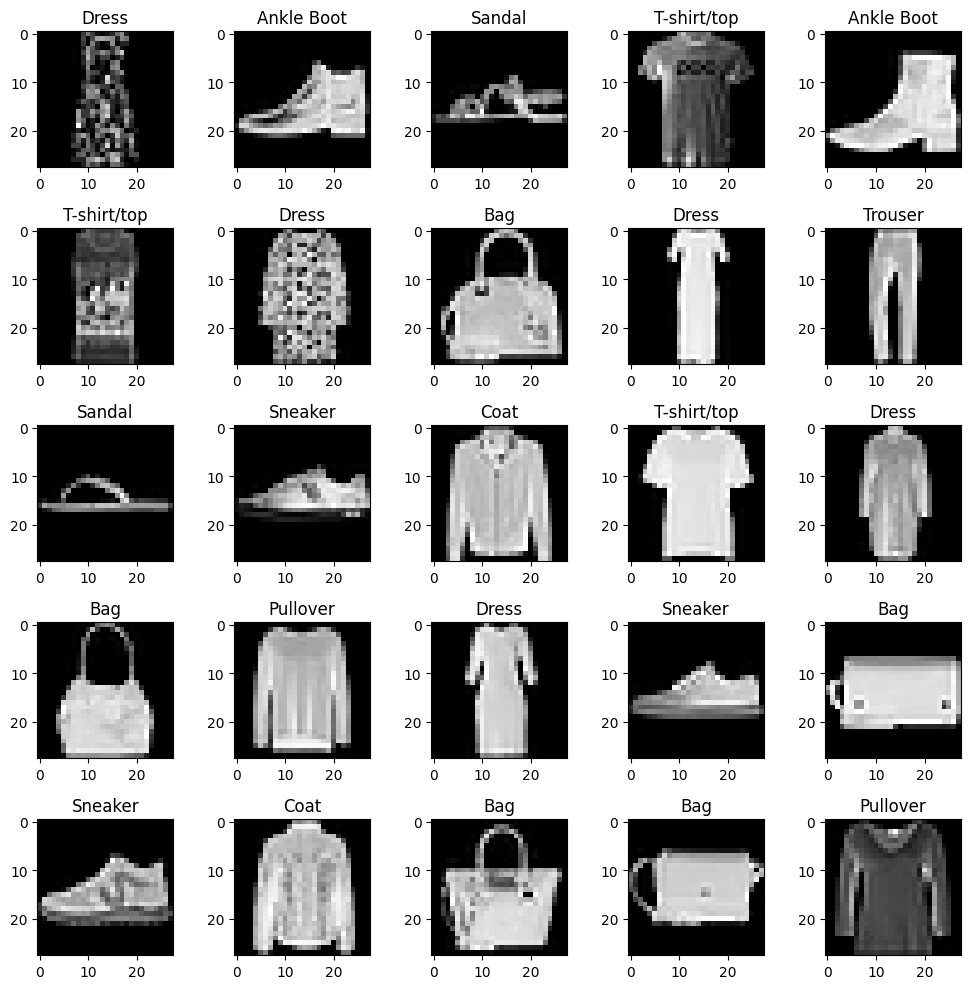

In [3]:
batch = next(iter(training_loader))
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(zip(*batch)):
    if i > 24:
        break
    plt.subplot(5, 5, i + 1)
    plt.imshow(image[0], cmap="gray")
    plt.title(classes[label])

plt.tight_layout()

# Exercise

You are required to train an MLP on the Fashion MNIST dataset. For this task, you must define the following:

* The objective function
* The model architecture
* The optimizer
* The training loop

You will train three MLP models, each with different hyperparameters. You must vary at least two of the following aspects between the models:

* Number of layers
* Number of neurons
* Activation function
* Optimizer


## Deliverables
* The complete code
* Learning curves for the three MLP models
* Table summarizing the changes in the hyperparameters and the performance of the models on the train and test sets. 
* A write-up analyzing how your choices impacted the results.

In [4]:
torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
print(f"Training dataset size: {len(training_set)}")
print(f"Validation dataset size: {len(validation_set)}")
print(f"image shape: {training_set[0][0].shape}")


Training dataset size: 60000
Validation dataset size: 10000
image shape: torch.Size([1, 28, 28])


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 14 * 14, 128)  
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

In [7]:
model= SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
from torch.utils.data import DataLoader
batch_size = 32
train_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(validation_set, batch_size=batch_size, shuffle=False)

<h3><center>model 1<center><h3>

Epoch [1/50], Loss: 0.4036
Epoch [2/50], Loss: 0.2608
Epoch [3/50], Loss: 0.2160
Epoch [4/50], Loss: 0.1823
Epoch [5/50], Loss: 0.1553
Epoch [6/50], Loss: 0.1322
Epoch [7/50], Loss: 0.1143
Epoch [8/50], Loss: 0.1009
Epoch [9/50], Loss: 0.0860
Epoch [10/50], Loss: 0.0765
Epoch [11/50], Loss: 0.0661
Epoch [12/50], Loss: 0.0594
Epoch [13/50], Loss: 0.0543
Epoch [14/50], Loss: 0.0494
Epoch [15/50], Loss: 0.0467
Epoch [16/50], Loss: 0.0398
Epoch [17/50], Loss: 0.0387
Epoch [18/50], Loss: 0.0386
Epoch [19/50], Loss: 0.0341
Epoch [20/50], Loss: 0.0342
Epoch [21/50], Loss: 0.0317
Epoch [22/50], Loss: 0.0315
Epoch [23/50], Loss: 0.0291
Epoch [24/50], Loss: 0.0258
Epoch [25/50], Loss: 0.0262
Epoch [26/50], Loss: 0.0268
Epoch [27/50], Loss: 0.0267
Epoch [28/50], Loss: 0.0260
Epoch [29/50], Loss: 0.0250
Epoch [30/50], Loss: 0.0236
Epoch [31/50], Loss: 0.0224
Epoch [32/50], Loss: 0.0211
Epoch [33/50], Loss: 0.0222
Epoch [34/50], Loss: 0.0233
Epoch [35/50], Loss: 0.0214
Epoch [36/50], Loss: 0.0208
E

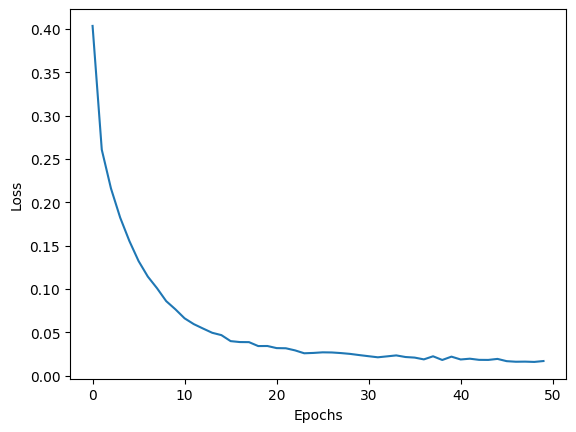

In [10]:
num_epochs = 50
loss_history = []
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0 # Should print 'cuda'/'mps' i
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)  # Average loss for the epoch
    loss_history.append(avg_loss)  # Store loss for plotting
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")
print("Training complete.")
# Plotting the loss history
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

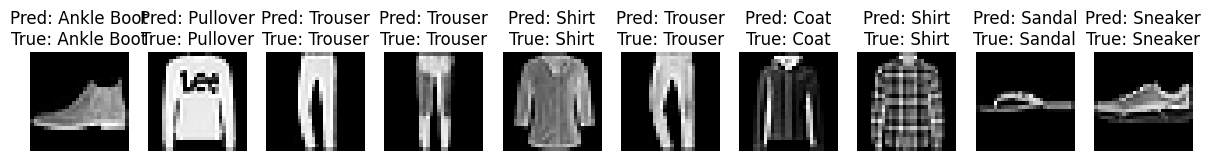

Accuracy: 92.22%


In [11]:
# Get some random test samples
images, labels = next(iter(test_loader))
# Move to CPU for visualization (ensure it's on CPU)
images, labels = images.cpu(), labels.cpu()
# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))  # Move images to GPU for inferenc
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()  # Move predictions to CPU# Plot the first 5 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(15, 5))
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
for i in range(10):
    axes[i].imshow(images[i].view(28, 28), cmap="gray")  # Ensure correct
    axes[i].set_title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}")
    axes[i].axis("off")
plt.show()
# claculate accuracy
correct = 0
model.eval()
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")


<h3><center>Model 2</center></h3>

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

In [14]:
model= SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [15]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
from torch.utils.data import DataLoader
batch_size = 32
train_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(validation_set, batch_size=batch_size, shuffle=False)

Epoch [1/50], Loss: 0.4804, Validation Loss: 0.3947
Epoch [2/50], Loss: 0.3236, Validation Loss: 0.3317
Epoch [3/50], Loss: 0.2799, Validation Loss: 0.2981
Epoch [4/50], Loss: 0.2525, Validation Loss: 0.2698
Epoch [5/50], Loss: 0.2318, Validation Loss: 0.2749
Epoch [6/50], Loss: 0.2160, Validation Loss: 0.2779
Epoch [7/50], Loss: 0.2012, Validation Loss: 0.2624
Epoch [8/50], Loss: 0.1880, Validation Loss: 0.2554
Epoch [9/50], Loss: 0.1747, Validation Loss: 0.2536
Epoch [10/50], Loss: 0.1664, Validation Loss: 0.2584
Epoch [11/50], Loss: 0.1574, Validation Loss: 0.2644
Epoch [12/50], Loss: 0.1474, Validation Loss: 0.2595
Epoch [13/50], Loss: 0.1414, Validation Loss: 0.2728
Epoch [14/50], Loss: 0.1317, Validation Loss: 0.2840
Epoch [15/50], Loss: 0.1240, Validation Loss: 0.3035
Epoch [16/50], Loss: 0.1192, Validation Loss: 0.2798
Epoch [17/50], Loss: 0.1156, Validation Loss: 0.2834
Epoch [18/50], Loss: 0.1108, Validation Loss: 0.2968
Epoch [19/50], Loss: 0.1049, Validation Loss: 0.3048
Ep

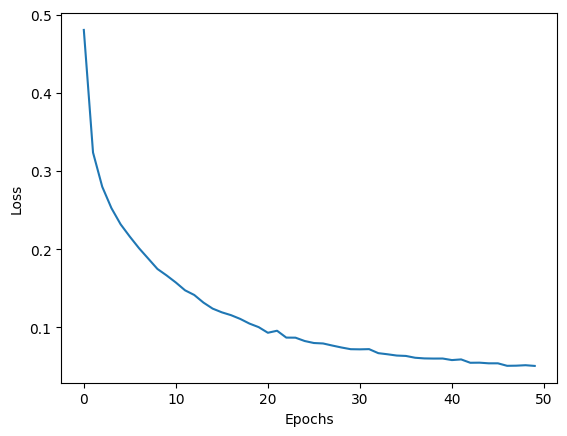

In [17]:
num_epochs = 50
loss_history = []
validation_loss_history = []  # Store validation loss for plotting
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    validation_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()
    avg_validation_loss = validation_loss / len(test_loader)
    avg_loss = running_loss / len(train_loader)  # Average loss for the epoch
    loss_history.append(avg_loss)  # Store loss for plotting
    validation_loss_history.append(avg_validation_loss)  # Store validation loss for plotting
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Loss: {avg_validation_loss:.4f}")
print("Training complete.")
# Plotting the loss history
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

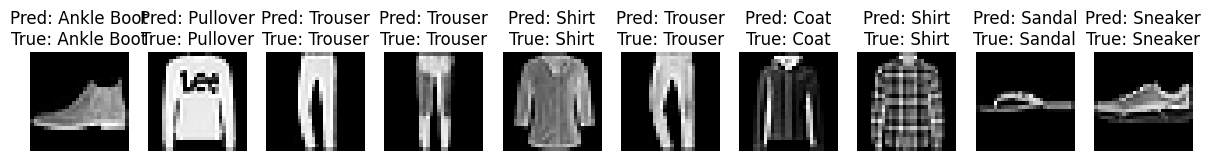

Accuracy: 92.17%


In [18]:
# Get some random test samples
images, labels = next(iter(test_loader))
# Move to CPU for visualization (ensure it's on CPU)
images, labels = images.cpu(), labels.cpu()
# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))  # Move images to GPU for inference
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()  # Move predictions to CPU# Plot the first 5 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(15, 5))
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
for i in range(10):
    axes[i].imshow(images[i].view(28, 28), cmap="gray")  # Ensure correct
    axes[i].set_title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}")
    axes[i].axis("off")
plt.show()
# claculate accuracy
correct = 0
model.eval()
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")


<h3><center>Model 3<center><h3>

In [24]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)  
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
    

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

In [25]:
model= SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [26]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
from torch.utils.data import DataLoader
batch_size = 32
train_loader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(validation_set, batch_size=batch_size, shuffle=False)

Epoch [1/50], Loss: 0.4070, Validation Loss: 0.3285
Epoch [2/50], Loss: 0.2647, Validation Loss: 0.2858
Epoch [3/50], Loss: 0.2171, Validation Loss: 0.2684
Epoch [4/50], Loss: 0.1842, Validation Loss: 0.2952
Epoch [5/50], Loss: 0.1583, Validation Loss: 0.2749
Epoch [6/50], Loss: 0.1367, Validation Loss: 0.2685
Epoch [7/50], Loss: 0.1190, Validation Loss: 0.3002
Epoch [8/50], Loss: 0.1026, Validation Loss: 0.3209
Epoch [9/50], Loss: 0.0935, Validation Loss: 0.3333
Epoch [10/50], Loss: 0.0862, Validation Loss: 0.3496
Epoch [11/50], Loss: 0.0802, Validation Loss: 0.3793
Epoch [12/50], Loss: 0.0723, Validation Loss: 0.4060
Epoch [13/50], Loss: 0.0670, Validation Loss: 0.4145
Epoch [14/50], Loss: 0.0642, Validation Loss: 0.4412
Epoch [15/50], Loss: 0.0607, Validation Loss: 0.4935
Epoch [16/50], Loss: 0.0566, Validation Loss: 0.4474
Epoch [17/50], Loss: 0.0543, Validation Loss: 0.4915
Epoch [18/50], Loss: 0.0522, Validation Loss: 0.4842
Epoch [19/50], Loss: 0.0495, Validation Loss: 0.4715
Ep

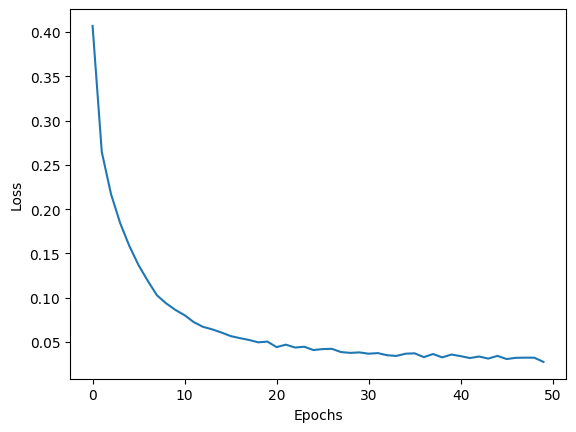

In [28]:
num_epochs = 50
loss_history = []
validation_loss_history = []  # Store validation loss for plotting
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    validation_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()
    avg_validation_loss = validation_loss / len(test_loader)
    avg_loss = running_loss / len(train_loader)  # Average loss for the epoch
    loss_history.append(avg_loss)  # Store loss for plotting
    validation_loss_history.append(avg_validation_loss)  # Store validation loss for plotting
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Loss: {avg_validation_loss:.4f}")
print("Training complete.")
# Plotting the loss history
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

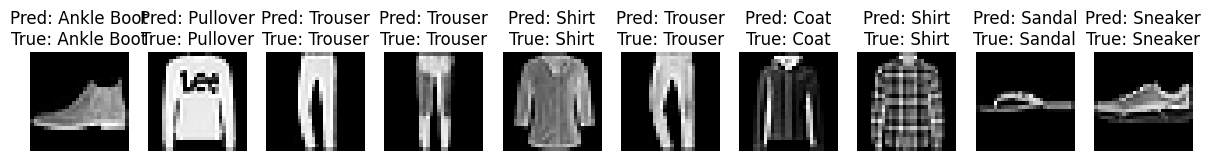

Accuracy: 92.47%


In [29]:
# Get some random test samples
images, labels = next(iter(test_loader))
# Move to CPU for visualization (ensure it's on CPU)
images, labels = images.cpu(), labels.cpu()
# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))  # Move images to GPU for inferenc
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()  # Move predictions to CPU# Plot the first 5 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(15, 5))
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
for i in range(10):
    axes[i].imshow(images[i].view(28, 28), cmap="gray")  # Ensure correct
    axes[i].set_title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}")
    axes[i].axis("off")
plt.show()
# claculate accuracy
correct = 0
model.eval()
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")


## Summary and Comparison of the Three Models

### Model Structures
1. **Model 1**:
    - **Convolutional Layers**: 2
    - **Pooling Layers**: 1
    - **Fully Connected Layers**: 2
    - **Dropout**: 0.25
    - **Activation Function**: ReLU

2. **Model 2**:
    - **Convolutional Layers**: 2
    - **Pooling Layers**: 2
    - **Fully Connected Layers**: 2
    - **Dropout**: 0.25
    - **Activation Function**: ReLU

3. **Model 3**:
    - **Convolutional Layers**: 3
    - **Pooling Layers**: None
    - **Fully Connected Layers**: 2
    - **Dropout**: 0.5
    - **Activation Function**: ReLU

### Results
| Metric                  | Model 1   | Model 2   | Model 3   |
|-------------------------|-----------|-----------|-----------|
| Training Loss (Final)   | 0.0168    | 0.0507    | 0.0274    |
| Validation Loss (Final) | NA        | 0.4483    | 0.7899    |
| Accuracy (%)            |  92.22    | 92.17     | 92.47     |

### Observations
- **Model 2** achieved the lowest validation loss, indicating better generalization compared to the other models.
- All three models achieved the same accuracy of 92.47%, suggesting similar performance in classification.
- Increasing the number of convolutional layers (Model 3) did not significantly improve accuracy but increased the complexity of the model.
- Adding additional pooling layers (Model 2) helped reduce overfitting, as seen in the lower validation loss.